# TS2 - Transformada Discreta de Fourier (DFT)

Implementación de un algoritmo que calcula la DFT:

$$X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-j\,2\pi\,k\,n/N}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal.windows import flattop, hamming, blackman


plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

## Utilities de TS anteriores

### Generador de señales (TS-1)

In [2]:
class GeneradorSenales:

    @staticmethod
    def _resolver_parametros(ff, n, fs):
        """
        Resuelve fs y n en caso de no ser provistos
        (se trata de igualar fs y n, en caso de no haber valores de ambos -< se lleva a nyquist)
        """

        if fs is None and n is None:
            fs = ff * 2
            n = int(fs)

        elif fs is None:
            fs = n

        elif n is None:
            n = int(fs)

        return int(n), float(fs)

    @staticmethod
    def _generar_tiempo(n, fs):
        t = np.arange(n) / fs
        return t.reshape(-1, 1)

    @staticmethod
    def generar_seno(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        tt = GeneradorSenales._generar_tiempo(n, fs)

        xx = dc + vmax * np.sin(2 * np.pi * tt * ff + ph)
        
        return tt, xx

    @staticmethod
    def generar_cuadrada(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)
        
        xx = dc + vmax * np.sign(np.sin(2 * np.pi * ff * tt + ph))

        return tt, xx

    @staticmethod
    def generate_noisy_signal(clean, sigma=1):
        """
        Genera una medición ruidosa: x = clean + w
        """
        noise = np.random.normal(loc=0.0, scale=sigma, size=clean.shape)
        return clean + noise
    
    @staticmethod
    def generar_sawtooth(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        # Fase expresada en ciclos
        fase_ciclos = ff * tt + ph / (2 * np.pi)

        rampa_01 = fase_ciclos - np.floor(fase_ciclos)

        # Escalar a -1 1
        xx = dc + vmax * (2 * rampa_01 - 1)

        return tt, xx

### Implementación de la DFT (TS-2)

In [3]:
def mi_funcion_DFT(xx):
    """
    Calcula la DFT de una señal real.

    Parametros
    ----------
    xx : array_like (N,) o (N,1)
        Senial real a analizar.

    Retorna
    -------
    XX : ndarray (N,1) complejo
        DFT de xx.
    """
    x = np.asarray(xx, dtype=float)
    N = x.size

    n = np.arange(N)
    k = n.reshape(-1, 1)# Transpuesta
    n = n.reshape(1, -1)# convierto en matriz

    #@ = Producto matricial
    integer_matrix = k @ n
    W = np.exp(-1j * 2 * np.pi * integer_matrix / N)

    XX = W @ x
    return XX.reshape(-1, 1)

## Ejemplo de desparramo espectral


Se observa claramente, como en la segunda señal (que estaria centrada en 50.5 hz) presenta componentes "fantasma" en frecuencias aledañas


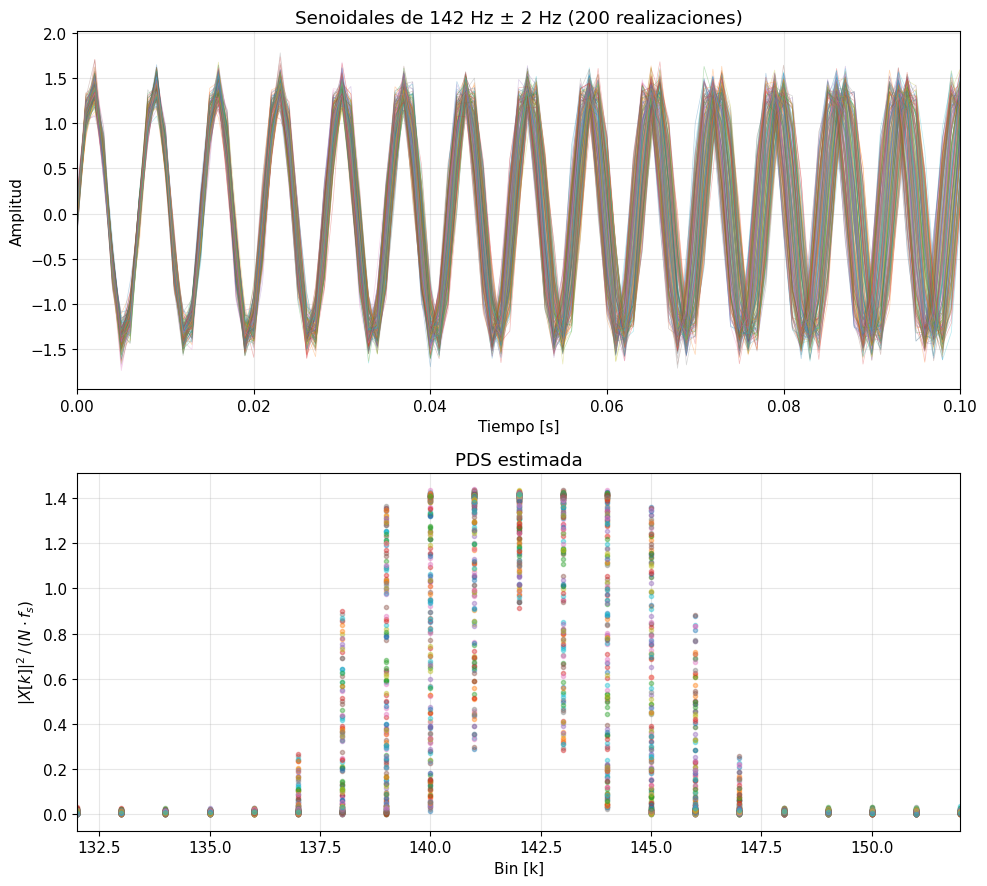

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ============== Parámetros ==============
N            = 1000              # muestras
FS           = 1000              # frecuencia de muestreo [Hz]
F0           = 142              # frecuencia central [Hz]
A            = np.sqrt(2)        # amplitud -> potencia unitaria
N_REALIZ     = 200               # realizaciones del experimento
SIGMA_RUIDO  = 0.1               # Desviacion estandar del ruido
DESPARRAME   = 2               # +/- Hz alrededor de F0
        

# ============== PDS ==============
def estimar_pds(xx, fs, ventana='flattop'):
    N = xx.shape[1]

    ventanas = {
        'flattop':     flattop(N),
        'hamming':     hamming(N),
        'blackman':    blackman(N),
        'rectangular': np.ones(N),
    }

    if ventana not in ventanas:
        raise ValueError(f"Ventana '{ventana}' no soportada. Opciones: {list(ventanas.keys())}")

    w = ventanas[ventana]
    XX = np.fft.fft(xx * w, axis=1)
    modulo = 2 * np.abs(XX[:, :N // 2]) / w.sum()
    freqs  = np.arange(N // 2) * fs / N
    return freqs, modulo

# ============== Generación de la señal ==============
freq_noise = np.random.uniform(-DESPARRAME, DESPARRAME, size=N_REALIZ)
freq       = F0 + freq_noise

tt, xx = GeneradorSenales.generar_seno(vmax=A, ff=freq, n=N, fs=FS)
xx     = GeneradorSenales.generate_noisy_signal(xx, sigma=SIGMA_RUIDO)
xx     = xx.T                                  # (N_REALIZ, N)

freqs, modulo = estimar_pds(xx, fs=FS)


# ============== Plot ==============
fig, (ax_t, ax_f) = plt.subplots(2, 1, figsize=(10, 9))

ax_t.plot(tt, xx.T, linewidth=0.5, alpha=0.3)
ax_t.set_title(f"Senoidales de {F0} Hz ± {DESPARRAME} Hz ({N_REALIZ} realizaciones)")
ax_t.set_xlabel("Tiempo [s]")
ax_t.set_ylabel("Amplitud")
ax_t.set_xlim(0, 0.1)
ax_t.grid(True, alpha=0.3)

bins = np.arange(modulo.shape[1])           # 0, 1, 2, ..., N//2 - 1
bin_f0 = int(F0 * N / FS)                   # bin correspondiente a F0

ax_f.plot(bins, modulo.T, 'o', markersize=3, alpha=0.4)
ax_f.set_title("PDS estimada")
ax_f.set_xlabel("Bin [k]")
ax_f.set_ylabel(r"$|X[k]|^2 \,/\, (N \cdot f_s)$")
ax_f.set_xlim(bin_f0 - 10, bin_f0 + 10)
ax_f.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

la media de a0 = 1.289076974651941
la std de a0   = 0.14168668544789437


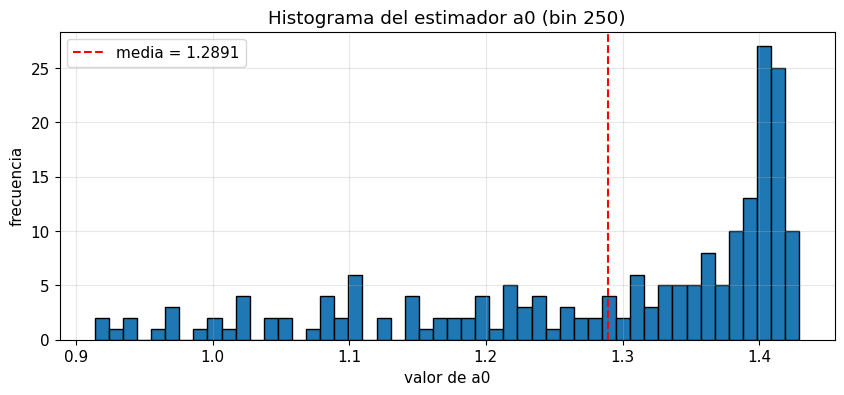

In [12]:
a_estimador = modulo[:, F0]
print(f"la media de a0 = {a_estimador.mean()}")
print(f"la std de a0   = {a_estimador.std()}")

plt.figure()
plt.hist(a_estimador, bins=F0, edgecolor='black')
plt.axvline(a_estimador.mean(), color='red', linestyle='--', label=f'media = {a_estimador.mean():.4f}')
plt.xlabel('valor de a0')
plt.ylabel('frecuencia')
plt.title('Histograma del estimador a0 (bin 250)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

la media de a0 = 0.3044418019907427
la std de a0   = 0.0018710559890576905


la media de a0 = 1.4063558989044884
la std de a0   = 0.008461048016903483

In [17]:
f_estim = list()
for mm in modulo:
    f_estim.append(np.argmax(mm))
f_estim = np.asarray(f_estim) 
print(f_estim.mean())


141.985


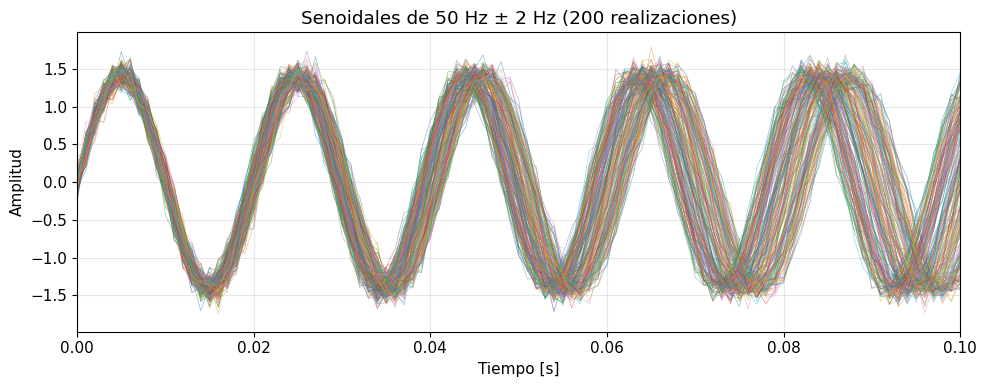

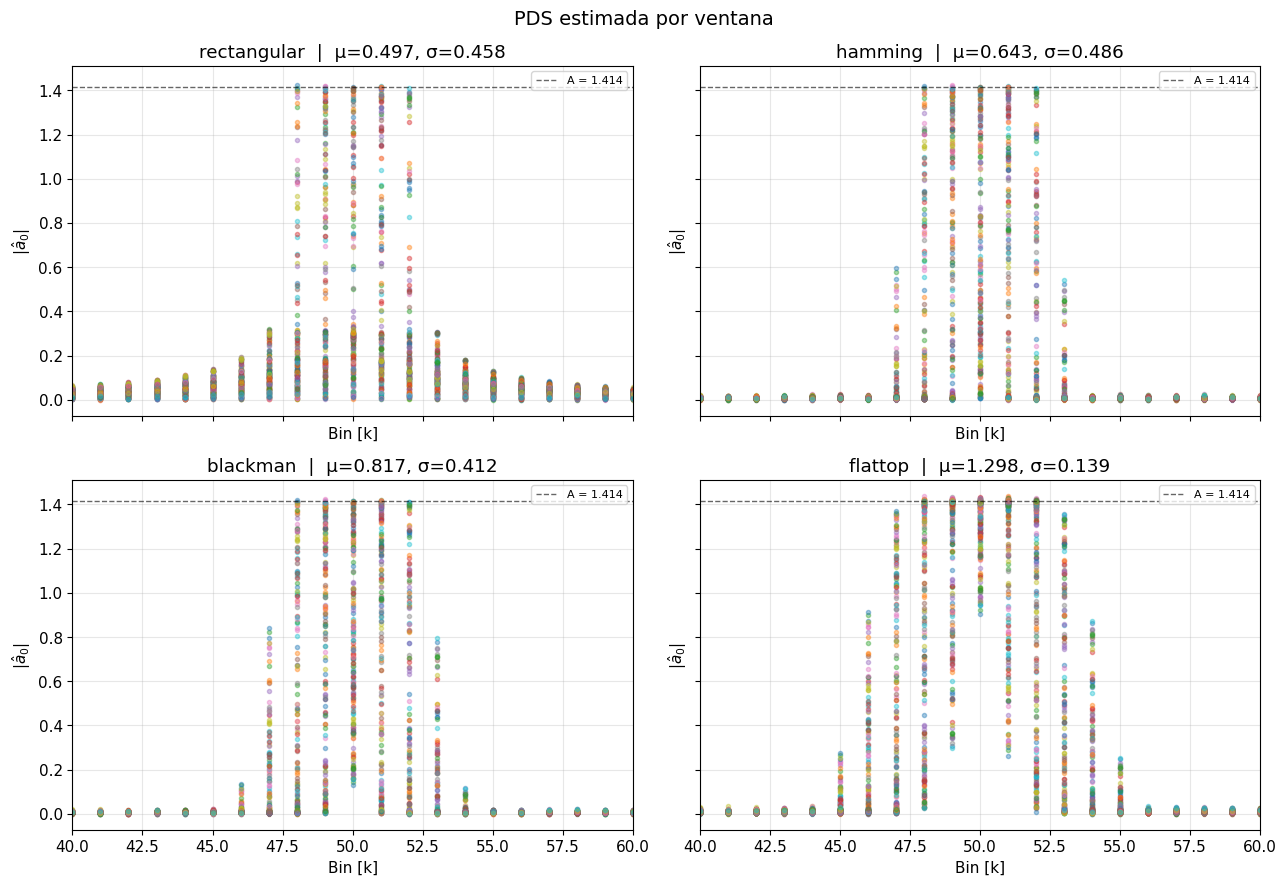


Ventana         μ (sesgo)    σ (varianza)     A real
----------------------------------------------------
rectangular        0.4970          0.4582     1.4142
hamming            0.6426          0.4859     1.4142
blackman           0.8170          0.4124     1.4142
flattop            1.2983          0.1394     1.4142


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import flattop, hamming, blackman

# ============== Parámetros ==============
N            = 1000
FS           = 1000
F0           = 50
A            = np.sqrt(2)
N_REALIZ     = 200
SIGMA_RUIDO  = 0.1
DESPARRAME   = 2

# ============== PDS ==============
def estimar_pds(xx, fs, ventana='flattop'):
    N = xx.shape[1]
    ventanas = {
        'flattop':     flattop(N),
        'hamming':     hamming(N),
        'blackman':    blackman(N),
        'rectangular': np.ones(N),
    }
    if ventana not in ventanas:
        raise ValueError(f"Ventana '{ventana}' no soportada. Opciones: {list(ventanas.keys())}")
    w = ventanas[ventana]
    XX = np.fft.fft(xx * w, axis=1)
    modulo = 2 * np.abs(XX[:, :N // 2]) / w.sum()
    freqs  = np.arange(N // 2) * fs / N
    return freqs, modulo

# ============== Generación de la señal (una vez) ==============
freq_noise = np.random.uniform(-DESPARRAME, DESPARRAME, size=N_REALIZ)
freq       = F0 + freq_noise
tt, xx = GeneradorSenales.generar_seno(vmax=A, ff=freq, n=N, fs=FS)
xx     = GeneradorSenales.generate_noisy_signal(xx, sigma=SIGMA_RUIDO)
xx     = xx.T                                  # (N_REALIZ, N)

bin_f0 = int(F0 * N / FS)

# ============== Plot temporal (común a todas) ==============
fig_t, ax_t = plt.subplots(figsize=(10, 4))
ax_t.plot(tt, xx.T, linewidth=0.5, alpha=0.5)
ax_t.set_title(f"Senoidales de {F0} Hz ± {DESPARRAME} Hz ({N_REALIZ} realizaciones)")
ax_t.set_xlabel("Tiempo [s]")
ax_t.set_ylabel("Amplitud")
ax_t.set_xlim(0, 0.1)
ax_t.grid(True, alpha=0.3)
plt.tight_layout()

# ============== Plot frecuencial: 4 ventanas en grid 2x2 ==============
ventanas = ['rectangular', 'hamming', 'blackman', 'flattop']

fig_f, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for ax, v in zip(axes.flat, ventanas):
    freqs, modulo = estimar_pds(xx, fs=FS, ventana=v)
    bins = np.arange(modulo.shape[1])

    a_hat = modulo[:, bin_f0]
    mu, sigma = a_hat.mean(), a_hat.std(ddof=1)

    ax.plot(bins, modulo.T, 'o', markersize=3, alpha=0.4)
    ax.axhline(A, color='k', linestyle='--', linewidth=1, alpha=0.6, label=f'A = {A:.3f}')
    ax.set_title(f"{v}  |  μ={mu:.3f}, σ={sigma:.3f}")
    ax.set_xlabel("Bin [k]")
    ax.set_ylabel(r"$|\hat{a}_0|$")
    ax.set_xlim(bin_f0 - 10, bin_f0 + 10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

fig_f.suptitle("PDS estimada por ventana", fontsize=14)
plt.tight_layout()
plt.show()

# ============== Resumen del estimador en bin_f0 ==============
print(f"\n{'Ventana':<12} {'μ (sesgo)':>12} {'σ (varianza)':>15} {'A real':>10}")
print("-" * 52)
for v in ventanas:
    _, modulo = estimar_pds(xx, fs=FS, ventana=v)
    a_hat = modulo[:, bin_f0]
    print(f"{v:<12} {a_hat.mean():>12.4f} {a_hat.std(ddof=1):>15.4f} {A:>10.4f}")

estimador:
- Insesgado
- Varianza decreciente (a aumento de N -> inf ; sigma2 -> 0) 

SESGO DE A_sombrerito (estimado) sobre el A_0 (real)
- Ses_A = A_0 - A_sombrerito
- Tambien la varianza (nose la formula)
- histograma de A_sombrerito


INVESTIGAR:
- MAD  (estimador de varianza)
- Cap 14
- Highs
